# Pfynwald HyPlant Coregistration Workflow

This notebook performs **geometric co-registration** of hyperspectral images using the **AROSICS** package (Scheffler et al. 2017).  
It aligns each image (from `shift_image_dir`) to a defined **reference image** (`ref_image_path`) through global coregistration.

Before and after co-registration, both the reference and target images are **cropped, masked and resampled (Lanczos)** to a defined **study area** (`study_area_path`) to:

- Ensure consistent spatial alignment,  
- Limit processing to the region of interest,  
- Maintain grid conformity after geometric correction.  

All resulting files are saved in `coreg_image_dir`.


#### Installation Notes — AROSICS on Windows

Installing **AROSICS** on Windows can be tricky due to dependencies like **GDAL**.  
Here’s the setup process that worked reliably for me:

```bash
# Create a new conda environment (Python 3.11)
conda create -c conda-forge --name arosics python=3.11
conda activate arosics

# Install GDAL first (this is often the main issue on Windows)
pip install gdal-installer
gdal-installer  # command-line setup for GDAL binaries

# Install required dependencies individually
pip install cartopy geopandas joblib matplotlib numpy pandas pyproj scikit-image shapely

# Finally, install AROSICS itself
pip install arosics
```

**Note:**  
The recommended installation via conda:

```bash
conda install -c conda-forge 'arosics>=1.3.0'
```

did **not** work for me due to the failing installation of GDAL.  


For further information, troubleshooting, and documentation, see: [AROSICS Official Documentation](https://danschef.git-pages.gfz-potsdam.de/arosics/doc/index.html)

In [56]:
# %%
# --- Basic imports ---
import os
import glob
import logging
from typing import Optional
import numpy as np
import geopandas as gpd
import rasterio
from rasterio.warp import reproject, Resampling
from rasterio.mask import mask
from rasterio.plot import show
from osgeo import gdal
import matplotlib.pyplot as plt


# AROSICS is used for coregistration.
from arosics import COREG

In [57]:
# %%
# --- Logging ---
logging.basicConfig(level=logging.INFO, format='[%(levelname)s] %(message)s')
logger = logging.getLogger(__name__)

In [58]:
# %%
# --- Configuration ---

# Paths
BASE_SHIFT_DIR = r"E:/Pfynwald/Data/HyPlant/original/"
COREG_DIR_BASE = r"E:/Pfynwald/Data/HyPlant/coregistration/"
STUDY_AREA_PATH = r"E:/Pfynwald/Data/studyarea.gpkg"

# Which folder inside BASE_SHIFT_DIR holds the input images you want to process
FOLDER = "SIF_SFM"

# File extension map and nodata map, different for the data sets
EXT_MAP = {
"TOC_REFL": "bsq",
"SIF_SFM": "bil",
"SIF_SFMNN":"dat",
"VI": "bsq",
"TASI": "dat"
}

NODATA_MAP = {
"TOC_REFL": -999,
"SIF_SFM": -999,
"SIF_SFMNN":-999,
"VI": -999,
"TASI": 0
}

# Reference image (set to the specific file you used before)
#REF_IMAGE_PATH = os.path.join(BASE_SHIFT_DIR, "VI","20240823-PHY-1248-1340-L1-E-DUAL_radiance_img_atm_pol_indices_up-rect.bsq")
REF_IMAGE_PATH = os.path.join(BASE_SHIFT_DIR, "TOC_REFL","20240823-PHY-1248-1340-L1-E-DUAL_radiance_img_atm_pol-rect.bsq")
#REF_IMAGE_PATH = os.path.join(BASE_SHIFT_DIR, "TASI","TASI_2024_06_13_094307_atm_g_LST.dat")

NODATA_ORIG = NODATA_MAP[FOLDER]
NODATA_REF = NODATA_MAP["VI"]

# Output directory for this run
OUT_DIR = os.path.join(COREG_DIR_BASE, FOLDER)
os.makedirs(OUT_DIR, exist_ok=True)


In [59]:
# %%
# --- AROSICS kwargs ---

# Important to fine-tune, 
# especially adjusting ws and s_b4match necessary to senure proper co-registration.

COREG_KWARGS = {
'ws': (64, 64), # matching window size [pixels] as (X, Y)
'nodata': (NODATA_REF, NODATA_ORIG), # no-data values for reference image and image to be shifted
'align_grids': False,
'fmt_out': 'ENVI', # raster file format for output file
'resamp_alg_deshift': 'lanczos', # the resampling algorithm to be used for shift correction
'max_shift': 5, # maximum shift distance in reference image pixel units
's_b4match': 2 # band of shift image to be used for matching (otherwise starts with 1; default: 1)
}

In [60]:
# %%
# --- Helper functions ---

def crop_to_study_area(
    in_raster: str,
    study_area_path: str,
    out_raster: str,
    reference_raster: Optional[str] = None,
    nodata_value: Optional[float] = None,
    resampling: Resampling = Resampling.lanczos, # sharper results than with Resampling.bilinear
    force_dtype: Optional[str] = None,
):
    """Crop and (optionally) reproject/resample `in_raster` to the study area or match a reference grid.

    Minimal, robust implementation used by the notebook cells.
    """

    with rasterio.open(in_raster) as src:
        src_crs = src.crs
        src_transform = src.transform
        src_count = src.count
        src_dtype = src.dtypes[0]
        src_nodata = src.nodata

        use_nodata = nodata_value if nodata_value is not None else src_nodata

        study_gdf = gpd.read_file(study_area_path)
        if study_gdf.crs is None:
            raise ValueError(f"Study area has no CRS: {study_area_path}")
        if study_gdf.crs != src_crs:
            study_gdf = study_gdf.to_crs(src_crs)

        study_union = study_gdf.unary_union
        geoms = [study_union]

        masked_image, masked_transform = mask(src, geoms, crop=True, nodata=use_nodata)

        masked_meta = src.meta.copy()
        masked_meta.update({
            'driver': 'GTiff',
            'height': masked_image.shape[1],
            'width': masked_image.shape[2],
            'transform': masked_transform,
            'nodata': use_nodata,
        })

    if reference_raster is None:
        out_dtype = force_dtype if force_dtype is not None else src_dtype
        masked_meta.update({'dtype': out_dtype, 'count': src_count})
        if force_dtype is not None and np.dtype(force_dtype) != np.dtype(masked_image.dtype):
            masked_image = masked_image.astype(force_dtype)
        with rasterio.open(out_raster, 'w', **masked_meta) as dst:
            dst.write(masked_image)
        logger.info(f'Wrote cropped raster to: {out_raster}')
        return

    with rasterio.open(reference_raster) as ref:
        ref_transform = ref.transform
        ref_crs = ref.crs
        ref_height = ref.height
        ref_width = ref.width
        ref_profile = ref.profile.copy()
        ref_nodata = ref.nodata

    dest_nodata = nodata_value if nodata_value is not None else (ref_nodata if ref_nodata is not None else 0)
    dest_dtype = force_dtype if force_dtype is not None else src_dtype

    out_data = np.full((src_count, ref_height, ref_width), dest_nodata, dtype=np.dtype(dest_dtype))

    for b in range(src_count):
        reproject(
            source=masked_image[b],
            destination=out_data[b],
            src_transform=masked_transform,
            src_crs=src_crs,
            dst_transform=ref_transform,
            dst_crs=ref_crs,
            resampling=resampling,
            src_nodata=use_nodata,
            dst_nodata=dest_nodata,
        )

    ref_profile.update({'driver': 'GTiff', 'dtype': dest_dtype, 'count': src_count, 'nodata': dest_nodata})

    with rasterio.open(out_raster, 'w', **ref_profile) as dst:
        dst.write(out_data)

    logger.info(f'Wrote reprojected raster matching reference grid to: {out_raster}')


# Small helper to display one band quickly
def quick_show(raster_path, band=1, title=None, cmap='viridis'):
    """
    Quick visualization helper.
    Automatically masks NoData values to improve contrast and display.
    """
    with rasterio.open(raster_path) as src:
        arr = src.read(band).astype(float)
        nodata = src.nodata

        # Mask nodata values
        if nodata is not None:
            arr = np.ma.masked_where(arr == nodata, arr)

        # Clip extreme values for better contrast
        vmin, vmax = np.percentile(arr.compressed(), (2, 98)) if arr.count() > 0 else (None, None)

        fig, ax = plt.subplots(figsize=(8, 6))
        show(arr, transform=src.transform, ax=ax, cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(title or os.path.basename(raster_path))
        plt.show()



In [61]:
# %%
# --- File discovery ---
INPUT_DIR = os.path.join(BASE_SHIFT_DIR, FOLDER)
pattern = f"*.{EXT_MAP[FOLDER]}" if not EXT_MAP[FOLDER].startswith('.') else f"*{EXT_MAP[FOLDER]}"
shift_images = glob.glob(os.path.join(INPUT_DIR, pattern))

# Optionally, subset images
shift_images = [p for p in shift_images if "2023" in os.path.basename(p)]

# Remove reference image from list for coregistration, but keep track if it exists
ref_in_shift = REF_IMAGE_PATH in shift_images
shift_images = [p for p in shift_images if os.path.abspath(p) != os.path.abspath(REF_IMAGE_PATH)]

print(f"Found {len(shift_images)} shift images (excluding reference) in: {INPUT_DIR}")
for p in shift_images:
    print(' -', os.path.basename(p))


Found 2 shift images (excluding reference) in: E:/Pfynwald/Data/HyPlant/original/SIF_SFM
 - 20230617-PHY-1117-1360-L1-E-FLUO_radiance_SFM_ALL-rect.bil
 - 20230617-PHY-1124-1360-L2-W-FLUO_radiance_SFM_ALL-rect.bil


Reference: E:/Pfynwald/Data/HyPlant/original/TOC_REFL\20240823-PHY-1248-1340-L1-E-DUAL_radiance_img_atm_pol-rect.bsq
Cropped output: E:/Pfynwald/Data/HyPlant/coregistration/SIF_SFM\ref_image_cropped.tif


C:\Users\avinn\AppData\Local\Temp\ipykernel_7892\4052301981.py:33: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  study_union = study_gdf.unary_union
[INFO] Wrote cropped raster to: E:/Pfynwald/Data/HyPlant/coregistration/SIF_SFM\ref_image_cropped.tif


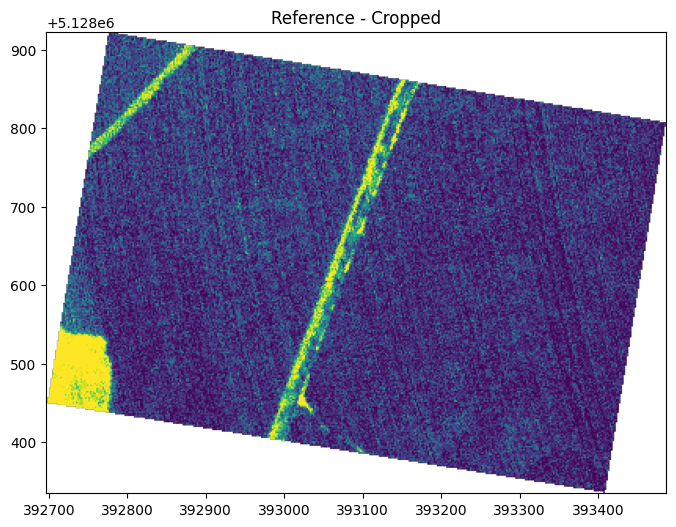


[INFO] Processing: 20230617-PHY-1117-1360-L1-E-FLUO_radiance_SFM_ALL-rect.bil


C:\Users\avinn\AppData\Local\Temp\ipykernel_7892\4052301981.py:33: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  study_union = study_gdf.unary_union
[INFO] Wrote reprojected raster matching reference grid to: E:/Pfynwald/Data/HyPlant/coregistration/SIF_SFM\tmp_cropped_20230617-PHY-1117-1360-L1-E-FLUO_radiance_SFM_ALL-rect.bil.tif
[INFO] Coregistering E:/Pfynwald/Data/HyPlant/coregistration/SIF_SFM\tmp_cropped_20230617-PHY-1117-1360-L1-E-FLUO_radiance_SFM_ALL-rect.bil.tif -> E:/Pfynwald/Data/HyPlant/coregistration/SIF_SFM\20230617-PHY-1117-1360-L1-E-FLUO_radiance_SFM_ALL-rect_coreg.tif
Polygonize progress     |==================================================| 100.0% Complete  => 0:00:00
Polygonize progress     |===============================================---| 94.2% Complete  => 0:00:00

Calculating footprint polygon and actual data corner coordinates for reference image...
Bounding box of calculated footprint for reference image:
	(392698.569, 5128334.964, 393486.569, 5128920.964)
Calculating footprint polygon and actual data corner coordinates for image to be shifted...


Polygonize progress     |==================================================| 100.0% Complete  => 0:00:00


Bounding box of calculated footprint for image to be shifted:
	(392698.569, 5128334.964, 393484.569, 5128920.964)
Matching window position (X,Y): 393092.24106515525/5128628.121054016
Detected integer shifts (X/Y):                            4/0
Detected subpixel shifts (X/Y):                           0.36198654770851135/-0.20608611404895782
Calculated total shifts in fft pixel units (X/Y):         4.361986547708511/-0.20608611404895782
Calculated total shifts in reference pixel units (X/Y):   4.361986547708511/-0.20608611404895782
Calculated total shifts in target pixel units (X/Y):      4.361986547708511/-0.20608611404895782
Calculated map shifts (X,Y):                              8.723973095417023/0.41217222809791565
Calculated absolute shift vector length in map units:     8.733704398202132
Calculated angle of shift vector in degrees from North:   267.29501904267613
Original map info: ['UTM', 1.0, 1.0, 392696.569, 5128922.964, 2.0, 2.0, 32, 'North', 'WGS-84']
Updated map info:  ['

C:\Users\avinn\AppData\Local\Temp\ipykernel_7892\4052301981.py:33: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  study_union = study_gdf.unary_union
[INFO] Wrote reprojected raster matching reference grid to: E:/Pfynwald/Data/HyPlant/coregistration/SIF_SFM\20230617-PHY-1117-1360-L1-E-FLUO_radiance_SFM_ALL-rect_coreg_resampled.tif


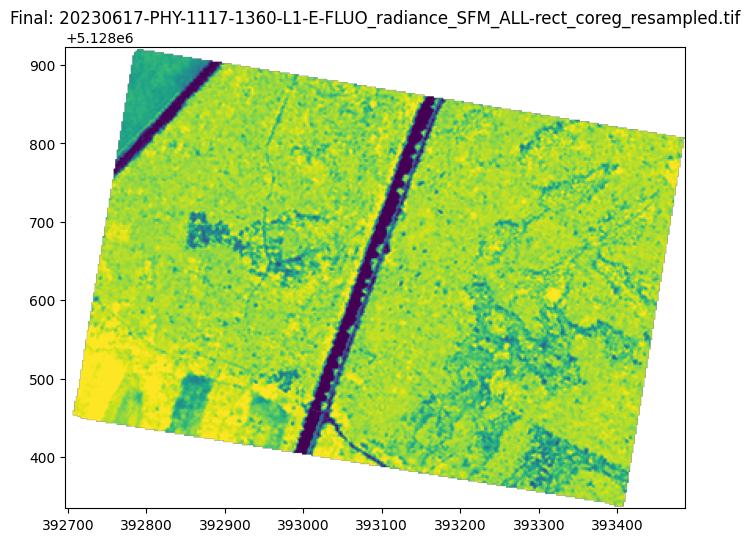


[INFO] Processing: 20230617-PHY-1124-1360-L2-W-FLUO_radiance_SFM_ALL-rect.bil


C:\Users\avinn\AppData\Local\Temp\ipykernel_7892\4052301981.py:33: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  study_union = study_gdf.unary_union
[INFO] Wrote reprojected raster matching reference grid to: E:/Pfynwald/Data/HyPlant/coregistration/SIF_SFM\tmp_cropped_20230617-PHY-1124-1360-L2-W-FLUO_radiance_SFM_ALL-rect.bil.tif
[INFO] Coregistering E:/Pfynwald/Data/HyPlant/coregistration/SIF_SFM\tmp_cropped_20230617-PHY-1124-1360-L2-W-FLUO_radiance_SFM_ALL-rect.bil.tif -> E:/Pfynwald/Data/HyPlant/coregistration/SIF_SFM\20230617-PHY-1124-1360-L2-W-FLUO_radiance_SFM_ALL-rect_coreg.tif
Polygonize progress     |==================================================| 100.0% Complete  => 0:00:00
Polygonize progress     |==================================================| 100.0% Complete  => 0:00:00
[ERROR] Coregistration failed for 20230617-PHY-1124-1360-L2-W-FLUO_radiance_SFM_ALL-rect.bil: No match found in the given window.


Calculating footprint polygon and actual data corner coordinates for reference image...
Bounding box of calculated footprint for reference image:
	(392698.569, 5128334.964, 393486.569, 5128920.964)
Calculating footprint polygon and actual data corner coordinates for image to be shifted...
Bounding box of calculated footprint for image to be shifted:
	(392698.569, 5128334.964, 393486.569, 5128920.964)
Matching window position (X,Y): 393092.5337023139/5128628.239475924
No clear match found yet. Jumping to iteration 2...
input shifts:  -3 -1
No clear match found yet. Jumping to iteration 3...
input shifts:  -2 -3
No clear match found yet. Jumping to iteration 4...
input shifts:  9 -12
No clear match found yet. Jumping to iteration 5...
input shifts:  2 -12

[INFO] Done. Processed images written to: E:/Pfynwald/Data/HyPlant/coregistration/SIF_SFM

[INFO] Done. Processed images written to: E:/Pfynwald/Data/HyPlant/coregistration/SIF_SFM


In [62]:
# %%
# --- Crop reference image ---
# Run to create a clean cropped reference used as the grid for reprojection
REF_CROPPED = os.path.join(OUT_DIR, 'ref_image_cropped.tif')
print('Reference:', REF_IMAGE_PATH)
print('Cropped output:', REF_CROPPED)

# Run the cell to crop the reference (manual execution)
crop_to_study_area(REF_IMAGE_PATH, STUDY_AREA_PATH, REF_CROPPED, reference_raster=None, nodata_value=NODATA_REF)
quick_show(REF_CROPPED, title='Reference - Cropped')

# --- Coregistration loop ---
for im_shift in shift_images:
    filename = os.path.basename(im_shift)
    print('\n[INFO] Processing:', filename)

    try:
        # 1) Crop target to study area and snap to ref grid
        tmp_cropped = os.path.join(OUT_DIR, f"tmp_cropped_{filename}.tif")
        crop_to_study_area(im_shift, STUDY_AREA_PATH, tmp_cropped,
                           reference_raster=REF_CROPPED, nodata_value=NODATA_ORIG)

        # 2) Coregister using AROSICS
        coreg_out = os.path.join(OUT_DIR, os.path.splitext(filename)[0] + '_coreg.tif')
        logger.info('Coregistering %s -> %s', tmp_cropped, coreg_out)

        cr = COREG(REF_CROPPED, tmp_cropped, path_out=coreg_out, **COREG_KWARGS)
        cr.correct_shifts()

        # 3) Clip/resample coregistered output to reference grid
        final_out = os.path.join(OUT_DIR, os.path.splitext(filename)[0] + '_coreg_resampled.tif')
        crop_to_study_area(coreg_out, STUDY_AREA_PATH, final_out,
                           reference_raster=REF_CROPPED, nodata_value=NODATA_ORIG)

        # Optional: quick visual check
        try:
            quick_show(final_out, title=f'Final: {os.path.basename(final_out)}')
        except Exception:
            logger.warning('Could not quick-show %s', final_out)

    except Exception as e:
        logger.error("Coregistration failed for %s: %s", filename, e)
        continue  # Skip to next image

    # Clean up temporary files
    for tmp in (tmp_cropped, coreg_out):
        try:
            os.remove(tmp)
        except OSError:
            pass

print('\n[INFO] Done. Processed images written to:', OUT_DIR)


# %%
# --- Process reference image if it was originally in shift images ---
if ref_in_shift:
    ref_filename = os.path.basename(REF_IMAGE_PATH)
    ref_cropped_snap = os.path.join(OUT_DIR, f"{os.path.splitext(ref_filename)[0]}_coreg_resampled.tif")


    crop_to_study_area(
    REF_IMAGE_PATH,
    STUDY_AREA_PATH,
    out_raster=ref_cropped_snap,
    reference_raster=REF_CROPPED,
    nodata_value=NODATA_REF
    )
    quick_show(ref_cropped_snap, title='Reference Image - Cropped & Resampled')


print('\n[INFO] Done. Processed images written to:', OUT_DIR)